# 📰 Fake News Detection using Graph ML
## Notebook 1: Data Collection & Exploration

**Project Pipeline:**
```
01_data_exploration ➜ 02_graph_construction ➜ 03_gnn_training ➜ 04_visualization
```

**Dataset:** LIAR Dataset — 12,836 labeled short statements from PolitiFact  
**Labels:** We simplify 6 classes ➜ Binary (Real / Fake)

## Step 1 — Install & Import Libraries

In [1]:
# Install all required libraries
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install transformers datasets
!pip install scikit-learn networkx matplotlib seaborn wordcloud
!pip install pandas numpy
!pip install jupyter ipykernel

In [2]:
# Install required libraries
!pip install datasets transformers scikit-learn matplotlib seaborn wordcloud -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Step 2 — Download the LIAR Dataset

In [5]:
!wget https://raw.githubusercontent.com/tfs4/liar_dataset/master/train.tsv
!wget https://raw.githubusercontent.com/tfs4/liar_dataset/master/test.tsv
!wget https://raw.githubusercontent.com/tfs4/liar_dataset/master/valid.tsv



--2026-04-12 15:12:58--  https://raw.githubusercontent.com/tfs4/liar_dataset/master/train.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2408165 (2.3M) [text/plain]
Saving to: ‘train.tsv’

train.tsv           100%[===================>]   2.30M  --.-KB/s    in 0.04s   

2026-04-12 15:12:58 (52.8 MB/s) - ‘train.tsv’ saved [2408165/2408165]

--2026-04-12 15:12:59--  https://raw.githubusercontent.com/tfs4/liar_dataset/master/test.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 301118 (294K) [text/plain]
Saving to: ‘test.tsv’


In [18]:
import pandas as pd

columns = [
    "id", "label", "statement", "subject",
    "speaker", "job", "state", "party",
    "barely_true", "false", "half_true",
    "mostly_true", "pants_on_fire", "context"
]

train_df = pd.read_csv("train.tsv", sep="\t", names=columns)
val_df   = pd.read_csv("valid.tsv", sep="\t", names=columns)
test_df  = pd.read_csv("test.tsv", sep="\t", names=columns)
df = pd.concat([train, valid, test])

print("✅ Dataset loaded:", df.shape)
df.head()

✅ Dataset loaded: (12791, 14)


,id,label,statement,subject,speaker,job,state,party,barely_true,false,half_true,mostly_true,pants_on_fire,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [19]:
def convert_label(label):
    fake = ['pants-fire', 'false', 'barely-true']
    return 1 if label in fake else 0

df['label'] = df['label'].apply(convert_label)

## Step 3 — Preprocess: 6 Labels ➜ Binary (Real / Fake)

In [20]:
# Convert 6-class labels → binary

def convert_label(label):
    fake_labels = ['pants-fire', 'false', 'barely-true']
    return 1 if label in fake_labels else 0

for df in [train_df, val_df, test_df]:
    # Clean text
    df['statement'] = df['statement'].astype(str).str.strip()
    df['speaker'] = df['speaker'].astype(str).str.strip()
    df['subject'] = df['subject'].astype(str).str.strip()

    # Store original label
    df['label_name'] = df['label']

    # Convert to binary
    df['binary_label'] = df['label'].apply(convert_label)

print("Train shape:", train_df.shape)
print("Fake:", (train_df['binary_label'] == 1).sum())
print("Real:", (train_df['binary_label'] == 0).sum())

Train shape: (10240, 16)
Fake: 4488
Real: 5752


## Step 4 — Exploratory Data Analysis (EDA)

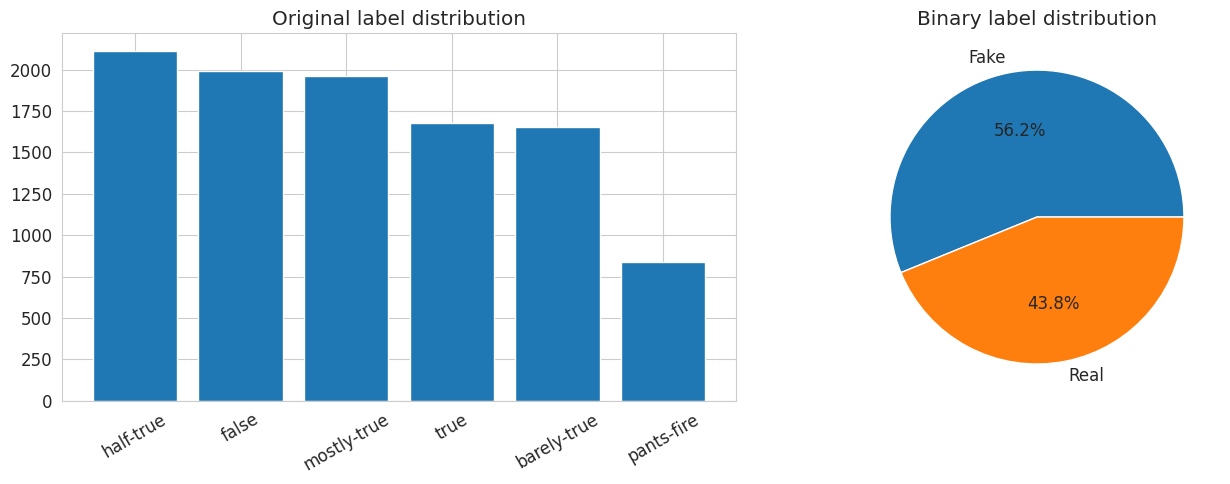

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original labels
label_counts = train_df['label_name'].value_counts()

axes[0].bar(label_counts.index, label_counts.values)
axes[0].set_title('Original label distribution')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Binary labels
binary_counts = train_df['binary_label'].value_counts()

axes[1].pie(binary_counts.values,
            labels=['Fake', 'Real'],
            autopct='%1.1f%%')

axes[1].set_title('Binary label distribution')

plt.tight_layout()
plt.show()

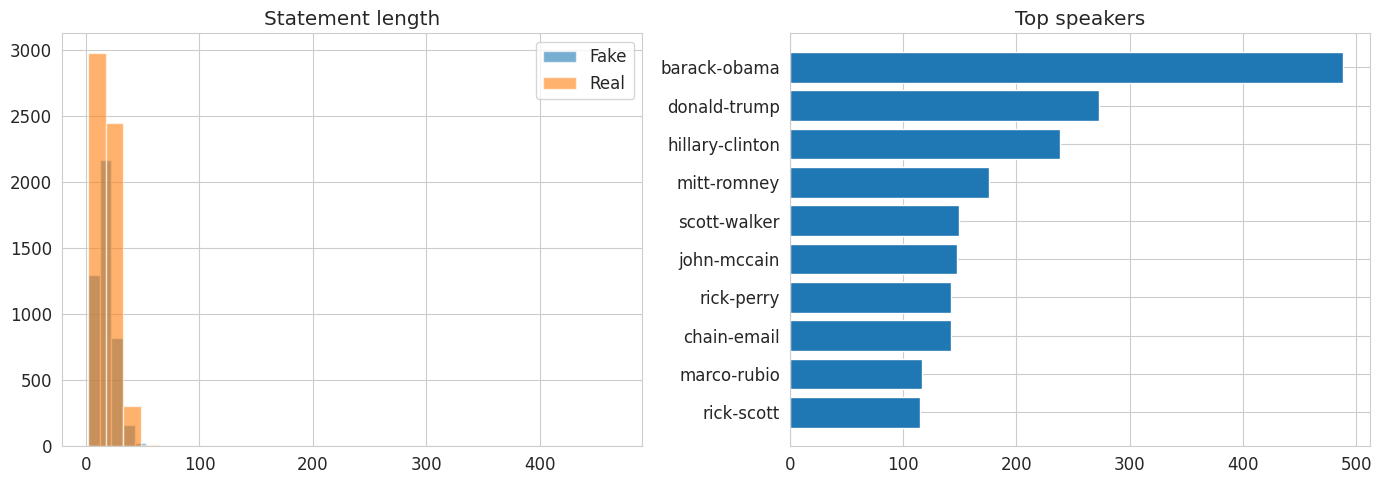

In [22]:
train_df['stmt_len'] = train_df['statement'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_lens = train_df[train_df.binary_label==1]['stmt_len']
real_lens = train_df[train_df.binary_label==0]['stmt_len']

axes[0].hist(fake_lens, bins=30, alpha=0.6, label='Fake')
axes[0].hist(real_lens, bins=30, alpha=0.6, label='Real')
axes[0].legend()
axes[0].set_title('Statement length')

# Top speakers
top_speakers = train_df['speaker'].value_counts().head(10)
axes[1].barh(top_speakers.index[::-1], top_speakers.values[::-1])
axes[1].set_title('Top speakers')

plt.tight_layout()
plt.show()

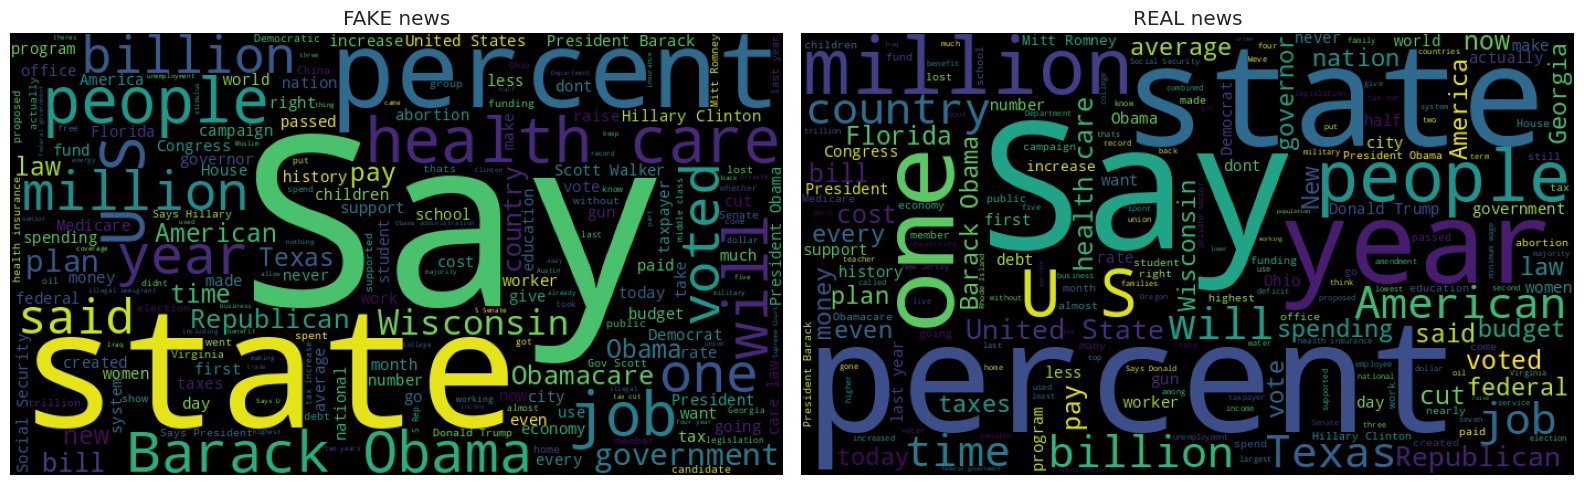

In [23]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label_val, title in zip(
        axes, [1, 0],
        ['FAKE news', 'REAL news']):

    text = ' '.join(train_df[train_df.binary_label == label_val]['statement'])

    wc = WordCloud(width=700, height=400).generate(text)

    ax.imshow(wc)
    ax.axis('off')
    ax.set_title(title)

plt.tight_layout()
plt.show()
plt.show()

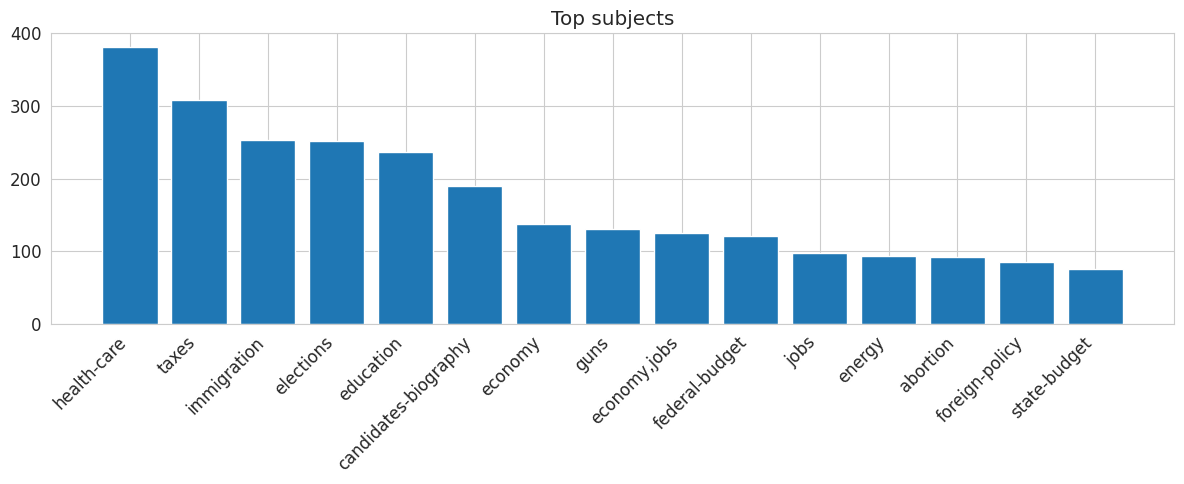

In [24]:
top_subjects = train_df['subject'].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_subjects.index, top_subjects.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top subjects')
plt.tight_layout()
plt.show()

## Step 5 — Save Processed Data

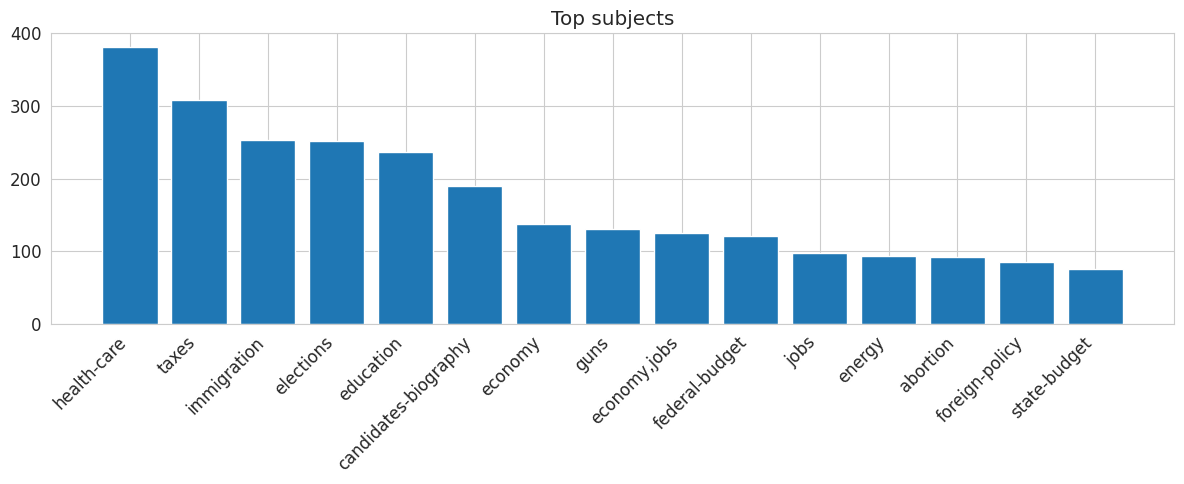

In [25]:
top_subjects = train_df['subject'].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_subjects.index, top_subjects.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top subjects')
plt.tight_layout()
plt.show()

In [26]:
import os
os.makedirs('data', exist_ok=True)

train_df.to_csv('data/train.csv', index=False)
val_df.to_csv('data/val.csv', index=False)
test_df.to_csv('data/test.csv', index=False)

print('✅ Data saved!')

✅ Data saved!
